<a href="https://colab.research.google.com/github/informatikasda-del/uts_visikomputer/blob/main/tugas_uts_visikomputer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

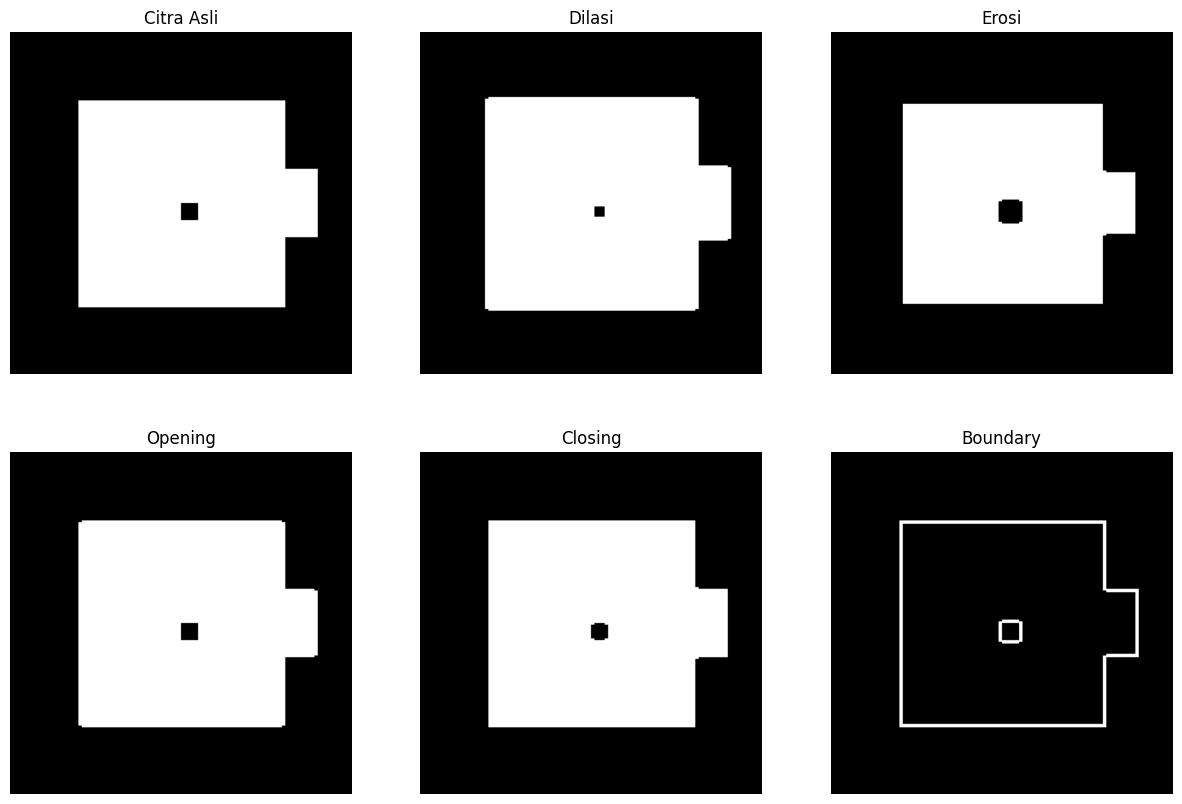

Hasil Membersihkan Objek yang Menyentuh Border:


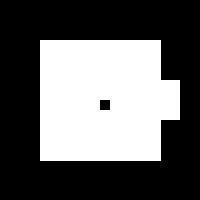

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# 1. Membuat Citra Biner Sederhana (Dataset Buatan)
img = np.zeros((200, 200), dtype=np.uint8)
cv2.rectangle(img, (40, 40), (160, 160), 255, -1) # Kotak utama
img[80:120, 150:180] = 255 # Tonjolan kecil (untuk uji opening)
img[100:110, 100:110] = 0   # Lubang kecil (untuk uji closing)

# 2. Mendefinisikan Structuring Element (Strel)
# Di dokumen disebut: strel('disk', 5), strel('square', 3), dll.
kernel_disk = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
kernel_rect = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# 3. Operasi Dasar (Sesuai Halaman 5 - 13)
# Dilasi (Penebalan)
dilation = cv2.dilate(img, kernel_disk, iterations=1)

# Erosi (Penipisan)
erosion = cv2.erode(img, kernel_disk, iterations=1)

# Opening (Erosi -> Dilasi): Menghilangkan tonjolan/noise kecil
opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel_disk)

# Closing (Dilasi -> Erosi): Menutup lubang/gap kecil
closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel_disk)

# 4. Operasi Lanjutan (Sesuai Halaman 18)
# Boundary Extraction (Tepi = Citra Asli - Erosi)
boundary = img - erosion

# 5. Visualisasi Hasil
titles = ['Citra Asli', 'Dilasi', 'Erosi', 'Opening', 'Closing', 'Boundary']
images = [img, dilation, erosion, opening, closing, boundary]

plt.figure(figsize=(15, 10))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()

# Contoh Membersihkan Border (Sesuai Halaman 31)
# imclearborder manual di OpenCV
mask = img.copy()
h, w = mask.shape
for y in range(h):
    for x in range(w):
        if x == 0 or y == 0 or x == w-1 or y == h-1:
            if mask[y, x] == 255:
                cv2.floodFill(mask, None, (x, y), 0)
print("Hasil Membersihkan Objek yang Menyentuh Border:")
cv2_imshow(mask)